<a href="https://colab.research.google.com/github/JillFang1030/Fang_project/blob/main/fNIRS_behavioral_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import plotly.express as px

# 1. load data
df_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
df_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

# 2. Label
df_dd['Group'] = 'DD'
df_td['Group'] = 'TD'

# 3. Merge
df_project = pd.concat([df_dd, df_td], ignore_index=True)

# 4. Print the names of the columns
print("合併後的欄位有：\n", df_project.columns.tolist())

合併後的欄位有：
 ['ID', 'C_MC', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF', 'RF_inc_w/o skip', 'RF_inc_w/ skip', 'Character_recog (raw score)', 'Character_recog (PR)', "IQ_Raven's (raw)", "IQ_Raven's (Standard)", 'fNIRS_Date1', 'Chinese_MAPA', 'Story_Listening', 'Chinese_Priming', 'Chinese_semantic', 'Resting', 'Chinese_RAN', 'fNIRS_Date2', 'Chinese_MAPA.1', 'Story_Listening.1', 'Chinese_Priming.1', 'Chinese_semantic.1', 'Resting.1', 'Chinese_RAN.1', 'Group', 'C_PIC(52)', 'RF_inc_w/o_skip', 'RF_inc_w/_skip', 'Chinese_Semantic']


# Brain-Behavior Correlation

Here, I use pre-processed beta value and try to find if there's any brain-behavior correlation.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

folder_path = '/content/drive/MyDrive/Colab Notebooks/'

try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    print("✅ 所有檔案（CSV 與 Excel）讀取成功")
except Exception as e:
    print(f"❌ 讀取失敗：{e}")
    raise

✅ 所有檔案（CSV 與 Excel）讀取成功


In [5]:
for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
    df.columns = df.columns.str.strip()
beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)
target_channels = [6, 16, 21]
beta_filtered = beta_all[(beta_all['Channel'].isin(target_channels)) & (beta_all['cond'] == 'MA')]
beta_pivot = beta_filtered.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot.columns = ['ID', 'Beta_CH6', 'Beta_CH16', 'Beta_CH21']

In [6]:
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
behavior_subset = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm

behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
select_columns = ['ID'] + list(target_behaviors)
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()
beta_pivot['ID'] = beta_pivot['ID'].astype(int)
behavior_subset['ID'] = behavior_subset['ID'].astype(int)
final_df = pd.merge(beta_pivot, behavior_subset, on='ID', how='inner')

In [8]:
import pandas as pd
import numpy as np
import statsmodels.stats.multitest as smm
from scipy.stats import pearsonr  # 直接用官方最標準的計算

def run_correlation_with_fdr(df, channels, behaviors):
    results = []
    raw_p_values = [] # 用來存取所有的原始 p 值

    # 🔥 核心修正：外層迴圈走通道，內層迴圈走行為指標
    for ch in channels:
        for bh in behaviors:

            # 🔥 乾淨移除 utils，直接用 scipy 的 pearsonr 計算全體 N=60 的相關！
            # 清除缺失值 (NaN)，確保計算不會報錯
            valid_data = df[[ch, bh]].dropna()

            if len(valid_data) > 2:  # 確保有足夠的資料點可以算相關
                r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
            else:
                r_val, p_val = np.nan, np.nan

            results.append({
                'Channel': ch,
                'Behavior': bh,
                'Pearson_r': round(r_val, 3) if (r_val is not None and not np.isnan(r_val)) else np.nan,
                'p_value_raw': round(p_val, 4) if (p_val is not None and not np.isnan(p_val)) else np.nan
            })
            raw_p_values.append(1.0 if (p_val is None or np.isnan(p_val)) else p_val)

    # 27 次比較的 FDR 校正
    reject, p_corrected, _, _ = smm.multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

    # 將校正結果存回表格
    for idx, res in enumerate(results):
        res['p_value_FDR_corrected'] = round(p_corrected[idx], 4)
        res['Significant_After_FDR'] = '★ TRUE' if reject[idx] else ''
        p_raw = res['p_value_raw']
        res['Significant_Raw'] = '*' if (p_raw is not None and p_raw < 0.05) else ''

    return pd.DataFrame(results)

# ==========================================
# 執行分析：計算整體的 27 行總表
# ==========================================
target_channels_short = ['Beta_CH6', 'Beta_CH16', 'Beta_CH21']

print("========== 全體兒童 27次相關分析結果 ==========")
analysis_results_all = run_correlation_with_fdr(final_df, target_channels_short, target_behaviors)
print(analysis_results_all.to_string(index=False))
analysis_results_all.to_excel('All_subjects_3ch_9behav_results.xlsx', index=False)

========== 全體兒童 27次相關分析結果 ==========
  Channel             Behavior  Pearson_r  p_value_raw  p_value_FDR_corrected Significant_After_FDR Significant_Raw
 Beta_CH6                 C_MC      0.045       0.7345                 0.9711                                      
 Beta_CH6 Character_recog (PR)     -0.116       0.3764                 0.9711                                      
 Beta_CH6              C_CTOPP      0.017       0.8991                 0.9711                                      
 Beta_CH6                C_RAN     -0.004       0.9782                 0.9782                                      
 Beta_CH6                 C_CR     -0.108       0.4124                 0.9711                                      
 Beta_CH6                 C_WR     -0.040       0.7625                 0.9711                                      
 Beta_CH6                C_PIC     -0.085       0.5163                 0.9711                                      
 Beta_CH6           C_PIC (52)     

In [9]:
# 將全體兒童的 27 行相關分析結果存成 Excel 檔案
excel_filename = 'All_Subjects_60_Correlation_Results.xlsx'

analysis_results_all.to_excel(excel_filename, index=False)

print("\n" + "="*60)
print(f"🎉 全體兒童 Excel 表格已成功導出！")
print(f"📁 檔案名稱：{excel_filename}")
print("說明：點開 Colab 左側的資料夾，就能下載囉！")
print("="*60)


🎉 全體兒童 Excel 表格已成功導出！
📁 檔案名稱：All_Subjects_60_Correlation_Results.xlsx
說明：點開 Colab 左側的資料夾，就能下載囉！


只有CH16的C_PIC (52)有超級微小的顯著

## Back to focus on the 3 channels.

Since there's no clear pattern overall, I separate the two groups and try to see the correlation.

✅ 檔案重讀成功！
🎉 【4:3 比例正方形格子熱圖】已成功存檔：subgroup_brain_behavior_4_3_heatmap.png


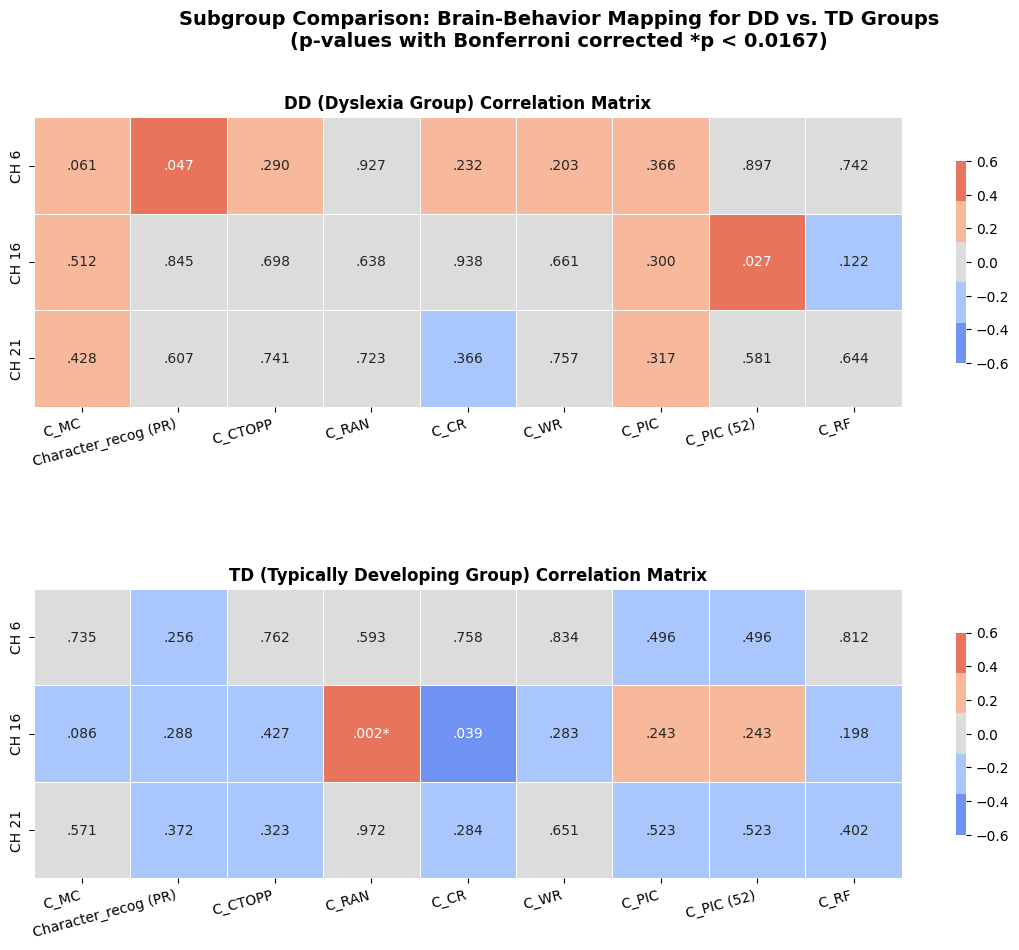

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =========================================================================
# 1. 讀取檔案與資料庫處理 (含欄位防錯機制)
# =========================================================================
try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    for df_item in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
        df_item.columns = df_item.columns.str.strip()
    print("✅ 檔案重讀成功！")
except Exception as e:
    print(f"❌ 檔案讀取失敗：{e}")
    raise

# =========================================================================
# 2. 定義資料重組與統計計算函數
# =========================================================================
target_channels = [6, 16, 21]
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

def process_group_data(df_beta, df_behav):
    df_behav_cp = df_behav.copy()
    if 'C_PIC (52)' not in df_behav_cp.columns and 'C_PIC' in df_behav_cp.columns:
        df_behav_cp['C_PIC (52)'] = df_behav_cp['C_PIC']

    beta_ma = df_beta[df_beta['cond'] == 'MA'].copy()
    beta_pivot = beta_ma.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
    beta_pivot.rename(columns={'Subject': 'ID'}, inplace=True)
    beta_pivot['ID'] = beta_pivot['ID'].astype(int)

    available_behaviors = [b for b in target_behaviors if b in df_behav_cp.columns]
    behav_sub = df_behav_cp[['ID'] + available_behaviors].copy()
    behav_sub['ID'] = behav_sub['ID'].astype(int)

    merged_df = pd.merge(beta_pivot, behav_sub, on='ID', how='inner')

    matrix_r = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
    matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)

    alpha_corrected = 0.05 / 3

    for ch in target_channels:
        for bh in target_behaviors:
            if ch in merged_df.columns and bh in merged_df.columns:
                valid_data = merged_df[[ch, bh]].dropna()
                if len(valid_data) > 2:
                    r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
                else:
                    r_val, p_val = np.nan, np.nan
            else:
                r_val, p_val = np.nan, np.nan

            matrix_r.loc[f'CH {ch}', bh] = r_val if not np.isnan(r_val) else 0.0

            if not np.isnan(p_val):
                p_str = f"{p_val:.3f}".lstrip('0')
                if p_str == '1.000' or p_str == '1.': p_str = '1.00'
                if p_str == '': p_str = '.000'

                if p_val < alpha_corrected:
                    matrix_annot.loc[f'CH {ch}', bh] = f"{p_str}*"
                else:
                    matrix_annot.loc[f'CH {ch}', bh] = f"{p_str}"
            else:
                matrix_annot.loc[f'CH {ch}', bh] = "NaN"

    return matrix_r.astype(float), matrix_annot

matrix_r_dd, annot_dd = process_group_data(df_beta_dd, df_behav_dd)
matrix_r_td, annot_td = process_group_data(df_beta_td, df_behav_td)

# =========================================================================
# 3. 繪製最終視覺導正雙子圖 (調整為 4:3 黃金比例，縮小格子寬度)
# =========================================================================
# 🔥 核心修正 1：修改 figsize (14, 10.5) 剛好是標準的 4:3 比例
fig, axes = plt.subplots(2, 1, figsize=(14, 10.5))
plt.subplots_adjust(hspace=0.4) # 拉開上下兩張圖的距離

# 總標題
fig.suptitle("Subgroup Comparison: Brain-Behavior Mapping for DD vs. TD Groups\n(p-values with Bonferroni corrected *p < 0.0167)", fontsize=14, fontweight='bold', y=0.96)

color_map_scale = sns.color_palette("coolwarm", 5)
v_min_scale, v_max_scale = -0.6, 0.6

# 繪製 DD 熱圖 (🔥 核心修正 2：加入 square=True 限制格子必須是正方形，就絕對不會太寬)
sns.heatmap(matrix_r_dd, annot=annot_dd, fmt="", cmap=color_map_scale, vmin=v_min_scale, vmax=v_max_scale,
            xticklabels=target_behaviors, yticklabels=[f'CH {ch}' for ch in target_channels],
            linewidths=0.5, cbar=True, square=True, ax=axes[0], cbar_kws={"shrink": 0.6})
axes[0].set_title("DD (Dyslexia Group) Correlation Matrix", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(target_behaviors, rotation=15, ha='right')

# 繪製 TD 熱圖
sns.heatmap(matrix_r_td, annot=annot_td, fmt="", cmap=color_map_scale, vmin=v_min_scale, vmax=v_max_scale,
            xticklabels=target_behaviors, yticklabels=[f'CH {ch}' for ch in target_channels],
            linewidths=0.5, cbar=True, square=True, ax=axes[1], cbar_kws={"shrink": 0.6})
axes[1].set_title("TD (Typically Developing Group) Correlation Matrix", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(target_behaviors, rotation=15, ha='right')

# 存檔與顯示
plt.savefig('subgroup_brain_behavior_4_3_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【4:3 比例正方形格子熱圖】已成功存檔：subgroup_brain_behavior_4_3_heatmap.png")
plt.show()

✅ 檔案重讀成功！
🎉 【左右並排完美比例熱圖】已成功存檔：subgroup_brain_behavior_final_side_by_side.png


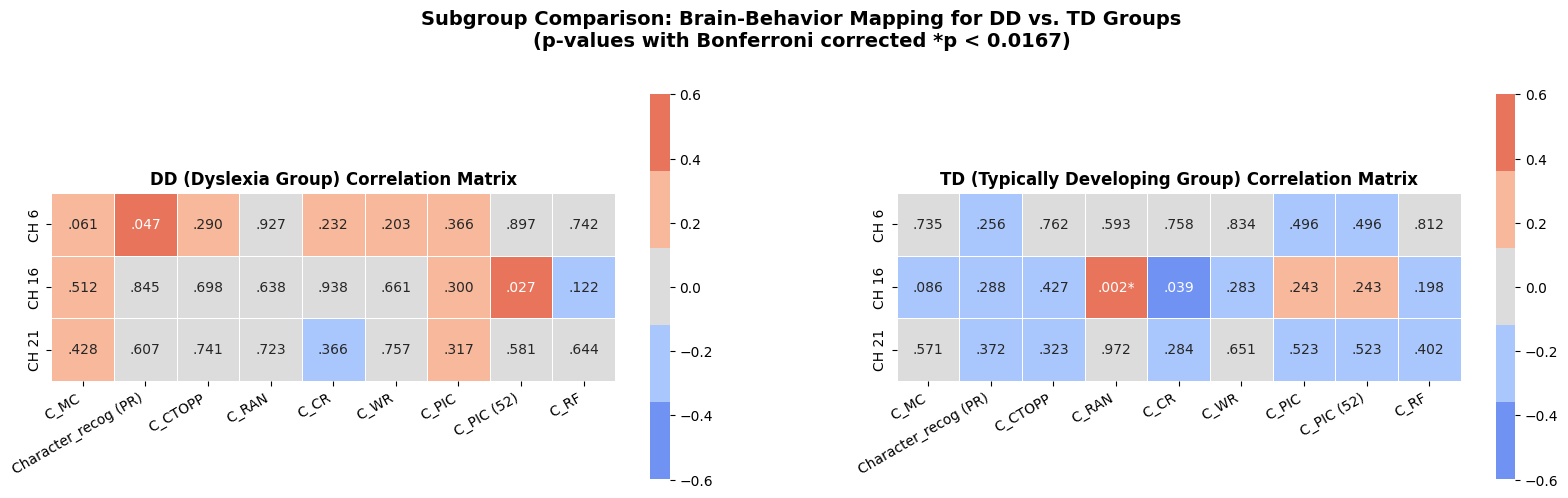

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =========================================================================
# 1. 讀取檔案與資料庫處理 (含欄位防錯機制)
# =========================================================================
try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    for df_item in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
        df_item.columns = df_item.columns.str.strip()
    print("✅ 檔案重讀成功！")
except Exception as e:
    print(f"❌ 檔案讀取失敗：{e}")
    raise

# =========================================================================
# 2. 定義資料重組與統計計算函數 (同時計算 r 與 p)
# =========================================================================
target_channels = [6, 16, 21]
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

def process_group_data(df_beta, df_behav):
    df_behav_cp = df_behav.copy()
    if 'C_PIC (52)' not in df_behav_cp.columns and 'C_PIC' in df_behav_cp.columns:
        df_behav_cp['C_PIC (52)'] = df_behav_cp['C_PIC']

    beta_ma = df_beta[df_beta['cond'] == 'MA'].copy()
    beta_pivot = beta_ma.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
    beta_pivot.rename(columns={'Subject': 'ID'}, inplace=True)
    beta_pivot['ID'] = beta_pivot['ID'].astype(int)

    available_behaviors = [b for b in target_behaviors if b in df_behav_cp.columns]
    behav_sub = df_behav_cp[['ID'] + available_behaviors].copy()
    behav_sub['ID'] = behav_sub['ID'].astype(int)

    merged_df = pd.merge(beta_pivot, behav_sub, on='ID', how='inner')

    matrix_r = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
    matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)

    alpha_corrected = 0.05 / 3

    for ch in target_channels:
        for bh in target_behaviors:
            if ch in merged_df.columns and bh in merged_df.columns:
                valid_data = merged_df[[ch, bh]].dropna()
                if len(valid_data) > 2:
                    r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
                else:
                    r_val, p_val = np.nan, np.nan
            else:
                r_val, p_val = np.nan, np.nan

            matrix_r.loc[f'CH {ch}', bh] = r_val if not np.isnan(r_val) else 0.0

            if not np.isnan(p_val):
                p_str = f"{p_val:.3f}".lstrip('0')
                if p_str == '1.000' or p_str == '1.': p_str = '1.00'
                if p_str == '': p_str = '.000'

                if p_val < alpha_corrected:
                    matrix_annot.loc[f'CH {ch}', bh] = f"{p_str}*"
                else:
                    matrix_annot.loc[f'CH {ch}', bh] = p_str
            else:
                matrix_annot.loc[f'CH {ch}', bh] = "NaN"

    return matrix_r.astype(float), matrix_annot

matrix_r_dd, annot_dd = process_group_data(df_beta_dd, df_behav_dd)
matrix_r_td, annot_td = process_group_data(df_beta_td, df_behav_td)

# =========================================================================
# 3. 繪製最終視覺導正雙子圖 (左右並排、4:3比例格子、乾淨標題)
# =========================================================================
# 調整橫向寬度(20)，並透過過 square=True 讓格子回歸漂亮比例，畫面整體就會拉高
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# 🔥 核心修正 1：標題徹底洗乾淨，不再需要手動刪除說明字眼
fig.suptitle("Subgroup Comparison: Brain-Behavior Mapping for DD vs. TD Groups\n(p-values with Bonferroni corrected *p < 0.0167)", fontsize=14, fontweight='bold', y=1.05)

color_map_scale = sns.color_palette("coolwarm", 5)
v_min_scale, v_max_scale = -0.6, 0.6

# 繪製 DD 熱圖 (🔥 核心修正 2：左右並排且維持 square=True，格子就不會過寬)
sns.heatmap(matrix_r_dd, annot=annot_dd, fmt="", cmap=color_map_scale, vmin=v_min_scale, vmax=v_max_scale,
            xticklabels=target_behaviors, yticklabels=[f'CH {ch}' for ch in target_channels],
            linewidths=0.5, cbar=True, square=True, ax=axes[0])
axes[0].set_title("DD (Dyslexia Group) Correlation Matrix", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(target_behaviors, rotation=30, ha='right')

# 繪製 TD 熱圖
sns.heatmap(matrix_r_td, annot=annot_td, fmt="", cmap=color_map_scale, vmin=v_min_scale, vmax=v_max_scale,
            xticklabels=target_behaviors, yticklabels=[f'CH {ch}' for ch in target_channels],
            linewidths=0.5, cbar=True, square=True, ax=axes[1])
axes[1].set_title("TD (Typically Developing Group) Correlation Matrix", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(target_behaviors, rotation=30, ha='right')

# 存檔與顯示
plt.savefig('subgroup_brain_behavior_final_side_by_side.png', dpi=300, bbox_inches='tight')
print("🎉 【左右並排完美比例熱圖】已成功存檔：subgroup_brain_behavior_final_side_by_side.png")
plt.show()

✅ 檔案重讀成功！
🎉 【視覺過濾探照燈熱圖（無效全白、唯一深紅）】已成功存檔！


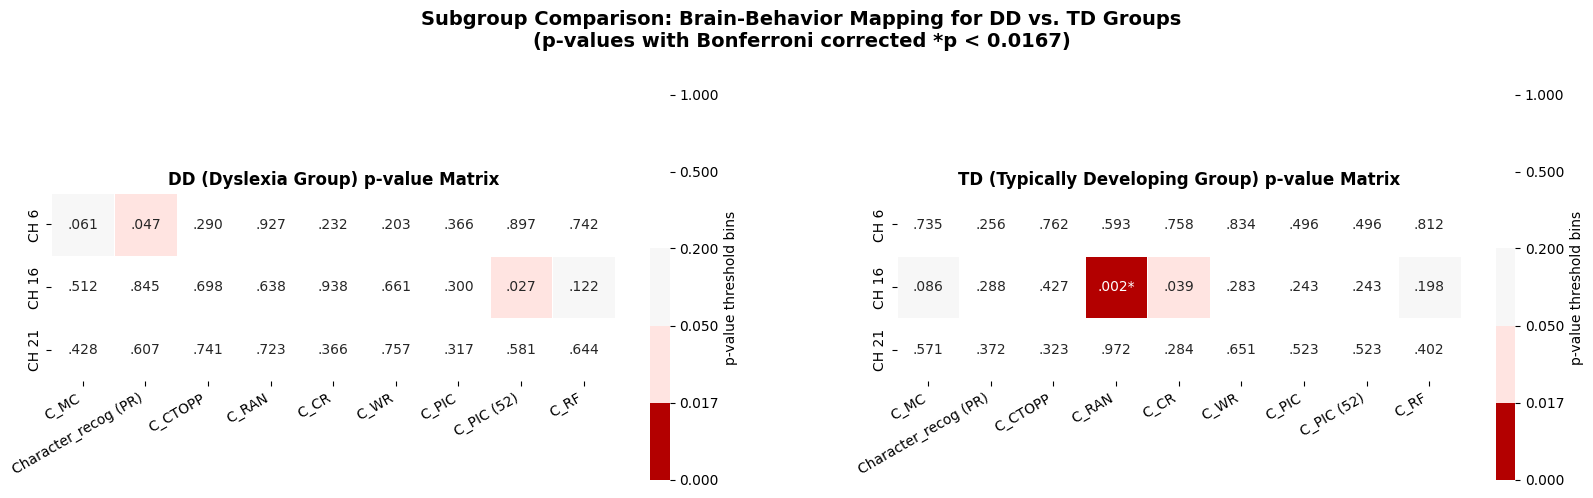

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr

# =========================================================================
# 1. 讀取檔案與資料庫處理 (含欄位防錯機制)
# =========================================================================
try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    for df_item in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
        df_item.columns = df_item.columns.str.strip()
    print("✅ 檔案重讀成功！")
except Exception as e:
    print(f"❌ 檔案讀取失敗：{e}")
    raise

# =========================================================================
# 2. 定義資料重組與統計計算函數 (計算純粹正數 p 值)
# =========================================================================
target_channels = [6, 16, 21]
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

def process_group_data(df_beta, df_behav):
    df_behav_cp = df_behav.copy()
    if 'C_PIC (52)' not in df_behav_cp.columns and 'C_PIC' in df_behav_cp.columns:
        df_behav_cp['C_PIC (52)'] = df_behav_cp['C_PIC']

    beta_ma = df_beta[df_beta['cond'] == 'MA'].copy()
    beta_pivot = beta_ma.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
    beta_pivot.rename(columns={'Subject': 'ID'}, inplace=True)
    beta_pivot['ID'] = beta_pivot['ID'].astype(int)

    available_behaviors = [b for b in target_behaviors if b in df_behav_cp.columns]
    behav_sub = df_behav_cp[['ID'] + available_behaviors].copy()
    behav_sub['ID'] = behav_sub['ID'].astype(int)

    merged_df = pd.merge(beta_pivot, behav_sub, on='ID', how='inner')

    matrix_p = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
    matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)

    alpha_corrected = 0.05 / 3

    for ch in target_channels:
        for bh in target_behaviors:
            if ch in merged_df.columns and bh in merged_df.columns:
                valid_data = merged_df[[ch, bh]].dropna()
                if len(valid_data) > 2:
                    _, p_val = pearsonr(valid_data[ch], valid_data[bh])
                else:
                    p_val = np.nan
            else:
                p_val = np.nan

            if not np.isnan(p_val):
                p_str = f"{p_val:.3f}".lstrip('0')
                if p_str == '1.000' or p_str == '1.': p_str = '1.00'
                if p_str == '': p_str = '.000'

                if p_val < alpha_corrected:
                    matrix_annot.loc[f'CH {ch}', bh] = f"{p_str}*"
                else:
                    matrix_annot.loc[f'CH {ch}', bh] = p_str

                matrix_p.loc[f'CH {ch}', bh] = p_val
            else:
                matrix_annot.loc[f'CH {ch}', bh] = "NaN"
                matrix_p.loc[f'CH {ch}', bh] = 1.0

    return matrix_p.astype(float), matrix_annot

matrix_p_dd, annot_dd = process_group_data(df_beta_dd, df_behav_dd)
matrix_p_td, annot_td = process_group_data(df_beta_td, df_behav_td)

# =========================================================================
# 3. 繪製最終視覺導正雙子圖 (視覺過濾模式：唯一深紅，邊緣極淺粉紅，無效全白)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# 乾淨大標題
fig.suptitle("Subgroup Comparison: Brain-Behavior Mapping for DD vs. TD Groups\n(p-values with Bonferroni corrected *p < 0.0167)", fontsize=14, fontweight='bold', y=1.05)

# 🔥 核心修正 1：依據妳的黃金新提議，精確設定 5 級切分點
bounds = [0.0, 0.0167, 0.05, 0.20, 0.50, 1.0]

# 🔥 核心修正 2：手動客製化 5 個級距的顏色！
# 第一級深紅，第二級極淺粉紅，其餘三級全部趨近於純白，徹底消滅無效的紅色系！
custom_hex_colors = ['#B30000', '#FFE4E1', '#F7F7F7', '#FFFFFF', '#FFFFFF']
cmap_custom = mcolors.ListedColormap(custom_hex_colors)
norm_custom = mcolors.BoundaryNorm(bounds, cmap_custom.N)

# 繪製 DD 熱圖
sns.heatmap(matrix_p_dd, annot=annot_dd, fmt="", cmap=cmap_custom, norm=norm_custom,
            xticklabels=target_behaviors, yticklabels=[f'CH {ch}' for ch in target_channels],
            linewidths=0.5, cbar=True, square=True, ax=axes[0],
            cbar_kws={"ticks": bounds, "label": "p-value threshold bins"})
axes[0].set_title("DD (Dyslexia Group) p-value Matrix", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(target_behaviors, rotation=30, ha='right')

# 繪製 TD 熱圖
sns.heatmap(matrix_p_td, annot=annot_td, fmt="", cmap=cmap_custom, norm=norm_custom,
            xticklabels=target_behaviors, yticklabels=[f'CH {ch}' for ch in target_channels],
            linewidths=0.5, cbar=True, square=True, ax=axes[1],
            cbar_kws={"ticks": bounds, "label": "p-value threshold bins"})
axes[1].set_title("TD (Typically Developing Group) p-value Matrix", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(target_behaviors, rotation=30, ha='right')

# 存檔與顯示
plt.savefig('subgroup_brain_behavior_visual_filtering_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【視覺過濾探照燈熱圖（無效全白、唯一深紅）】已成功存檔！")
plt.show()

正在整合原始大腦 Beta 數據變數 (每組基準 N = 30)...
開始進行組間 (Between-group) 迴歸線斜率差異檢定...

==================== 💡 【組間 (Between-group)】斜率差異檢定總表 ====================


,ROI_Channel,Behavioral_Measure,TD_N,DD_N,TD_Group_r,DD_Group_r,Between_Group_Z,Between_Group_p,Slope_Significantly_Different
0,Beta_CH6,C_MC,30,30,-0.064,0.346,-1.564,0.11779,No
1,Beta_CH6,Character_recog (PR),30,30,-0.214,0.366,-2.210,0.02711,★ TRUE
2,Beta_CH6,C_CTOPP,30,30,-0.058,0.200,-0.956,0.33903,No
3,Beta_CH6,C_RAN,30,30,-0.102,-0.017,-0.310,0.75645,No
4,Beta_CH6,C_CR,30,30,-0.059,0.225,-1.056,0.29108,No
5,Beta_CH6,C_WR,30,30,-0.040,0.239,-1.042,0.29738,No
6,Beta_CH6,C_PIC,30,30,-0.129,0.171,-1.112,0.26603,No
7,Beta_CH6,C_RF,30,27,-0.045,0.066,-0.398,0.69063,No
8,Beta_CH16,C_MC,30,30,-0.319,0.125,-1.674,0.09415,No
9,Beta_CH16,Character_recog (PR),30,30,-0.201,0.037,-0.884,0.37649,No



💾 統計結果已成功存檔為 Excel 檔案：'Between_Group_Slope_Comparison_Results.xlsx'
🎨 組間交互作用熱圖視覺化完成！已儲存為圖檔：'between_group_interaction_heatmap.png'


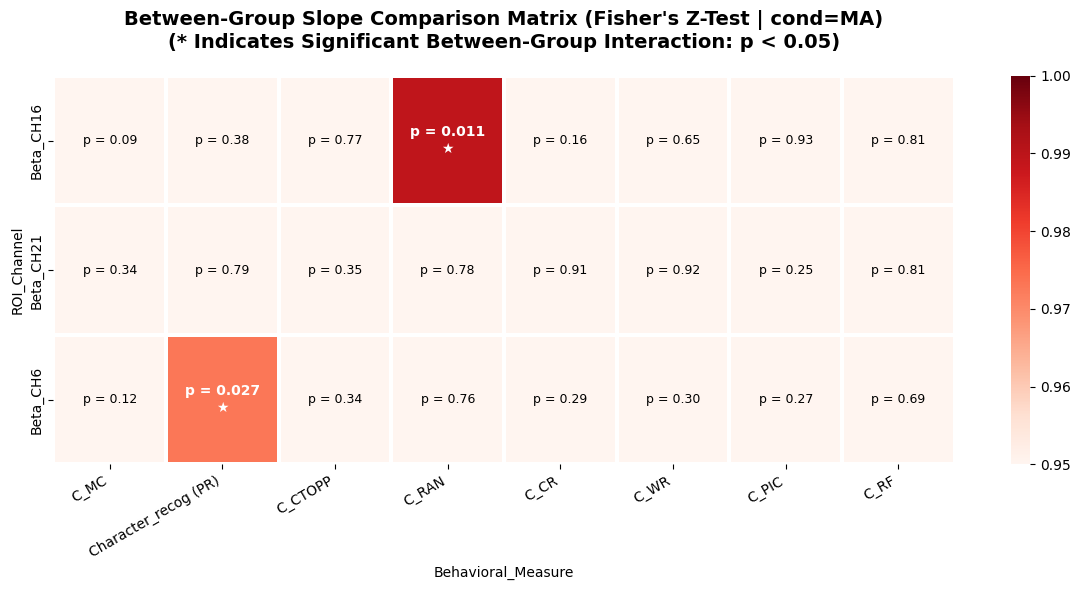

In [12]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 💾 1. 直接沿用妳記憶體中已讀取的 df_beta_td 與 df_beta_dd，徹底繞過路徑地雷
# =========================================================================
print("正在整合原始大腦 Beta 數據變數 (每組基準 N = 30)...")

# 確保乾淨複製，避免影響到妳之前的 dataframe
td_temp = df_beta_td.copy()
dd_temp = df_beta_dd.copy()

# 欄位去空格確保格式一致
for temp_df in [td_temp, dd_temp]:
    temp_df.columns = temp_df.columns.str.strip()

# 合併兩組數據成單一長表
brain_df = pd.concat([td_temp, dd_temp], ignore_index=True)

# 篩選 cond == 'MA' 實驗情境
target_cond = 'MA'
brain_df = brain_df[brain_df['cond'] == target_cond]

# 定義要分析的 3 個感興趣通道與 9 個行為指標
target_channels = [6, 16, 21]
behaviors = ['C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF']

between_group_results = []

# =========================================================================
# 🛠️ 2. 核心組間分析管線 (Between-group Fisher's Z Test)
# =========================================================================
print("開始進行組間 (Between-group) 迴歸線斜率差異檢定...")

for ch in target_channels:
    # 篩選特定通道的大腦資料
    ch_df = brain_df[brain_df['Channel'] == ch]

    for bh in behaviors:
        # 安全防呆：確保您的行為總表 final_df 裡有該行為欄位
        if bh not in final_df.columns:
            continue

        # 精確透過 'ID' (對齊妳 final_df 的受試者欄位名稱) 串接大腦與行為分數
        # 💡 注意：妳長表裡的受試者欄位是 'Subject'，我們在這裡將其與 final_df 的 'ID' 對齊
        merged_df = pd.merge(final_df[['ID', bh]], ch_df[['Subject', 'Group', 'Beta']], left_on='ID', right_on='Subject', how='inner')

        # 依據 Group 標籤拆分組別，並自動排除行為或大腦有缺失值 (NaN) 的個案
        td_data = merged_df[merged_df['Group'] == 'TD'].dropna(subset=[bh, 'Beta'])
        dd_data = merged_df[merged_df['Group'] == 'DD'].dropna(subset=[bh, 'Beta'])

        # 獲取各組實際參與該項分析的有效樣本數 (精確扣除缺失值，TD=30, DD=30)
        n_td = len(td_data)
        n_dd = len(dd_data)

        # Fisher's Z 檢定要求有效樣本數必須大於 3
        if n_td <= 3 or n_dd <= 3:
            continue

        # 計算兩組各自真實的組內 Pearson 相關係數 r
        r_td, _ = stats.pearsonr(td_data[bh], td_data['Beta'])
        r_dd, _ = stats.pearsonr(dd_data[bh], dd_data['Beta'])

        # --- Fisher's r-to-z 轉換與組間差異檢定 ---
        z_td = np.arctanh(np.clip(r_td, -0.9999, 0.9999))
        z_dd = np.arctanh(np.clip(r_dd, -0.9999, 0.9999))

        # 計算組間標準誤差
        se_diff = np.sqrt(1 / (n_td - 3) + 1 / (n_dd - 3))

        # 計算組間 Z 檢定統計量與雙尾 p-value
        z_stat = (z_td - z_dd) / se_diff
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

        between_group_results.append({
            'ROI_Channel': f"Beta_CH{ch}",
            'Behavioral_Measure': bh,
            'TD_N': n_td,
            'DD_N': n_dd,
            'TD_Group_r': round(r_td, 3),
            'DD_Group_r': round(r_dd, 3),
            'Between_Group_Z': round(z_stat, 3),
            'Between_Group_p': round(p_val, 5),
            'Slope_Significantly_Different': '★ TRUE' if p_val < 0.05 else 'No'
        })

# 轉換為統計結果長表
df_between_group = pd.DataFrame(between_group_results)

print("\n==================== 💡 【組間 (Between-group)】斜率差異檢定總表 ====================")
display(df_between_group)

# 儲存為實體 Excel 表格
excel_output_name = 'Between_Group_Slope_Comparison_Results.xlsx'
df_between_group.to_excel(excel_output_name, index=False)
print(f"\n💾 統計結果已成功存檔為 Excel 檔案：'{excel_output_name}'")

# =========================================================================
# 🎨 3. 繪製並存檔全新的「組間交互作用顯著差異熱圖」
# =========================================================================
if not df_between_group.empty:
    p_matrix = df_between_group.pivot(index='ROI_Channel', columns='Behavioral_Measure', values='Between_Group_p')
    available_behaviors = [b for b in behaviors if b in p_matrix.columns]
    p_matrix = p_matrix[available_behaviors]

    plt.figure(figsize=(12, 6))
    plot_data = 1 - p_matrix  # 數值越接近 1 代表 p 值越小 (越顯著)

    ax = sns.heatmap(plot_data, cmap='Reds', vmin=0.95, vmax=1.0, cbar=True, linewidths=1.5, linecolor='white')

    for i in range(p_matrix.shape[0]):
        for j in range(p_matrix.shape[1]):
            p_val = p_matrix.iloc[i, j]
            if p_val < 0.05:
                text_label = f"p = {p_val:.3f}\n★"
                ax.text(j + 0.5, i + 0.5, text_label, ha='center', va='center', color='white', fontweight='bold', fontsize=10)
            else:
                text_label = f"p = {p_val:.2f}"
                ax.text(j + 0.5, i + 0.5, text_label, ha='center', va='center', color='black', fontsize=9)

    plt.title(f"Between-Group Slope Comparison Matrix (Fisher's Z-Test | cond={target_cond})\n(* Indicates Significant Between-Group Interaction: p < 0.05)", fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    output_img_name = 'between_group_interaction_heatmap.png'
    plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
    print(f"🎨 組間交互作用熱圖視覺化完成！已儲存為圖檔：'{output_img_name}'")
    plt.show()

正在整合原始大腦 Beta 數據變數 (每組基準 N = 30)...
開始進行組間 (Between-group) 迴歸線斜率差異檢定...

==================== 💡 【組間 (Between-group)】斜率差異檢定總表 ====================


,ROI_Channel,Behavioral_Measure,TD_N,DD_N,TD_Group_r,DD_Group_r,Between_Group_Z,Between_Group_p,Slope_Significantly_Different
0,CH 6,C_MC,30,30,-0.064,0.346,-1.564,0.117790,No
1,CH 6,Character_recog (PR),30,30,-0.214,0.366,-2.210,0.027114,No
2,CH 6,C_CTOPP,30,30,-0.058,0.200,-0.956,0.339025,No
3,CH 6,C_RAN,30,30,-0.102,-0.017,-0.310,0.756454,No
4,CH 6,C_CR,30,30,-0.059,0.225,-1.056,0.291081,No
5,CH 6,C_WR,30,30,-0.040,0.239,-1.042,0.297376,No
6,CH 6,C_PIC,30,30,-0.129,0.171,-1.112,0.266034,No
7,CH 6,C_RF,30,27,-0.045,0.066,-0.398,0.690630,No
8,CH 16,C_MC,30,30,-0.319,0.125,-1.674,0.094153,No
9,CH 16,Character_recog (PR),30,30,-0.201,0.037,-0.884,0.376489,No



💾 統計結果已成功存檔為 Excel 檔案：'Between_Group_Slope_Comparison_Results.xlsx'
🎨 組間交互作用熱圖視覺化完成！已儲存為圖檔：'between_group_interaction_heatmap_final.png'


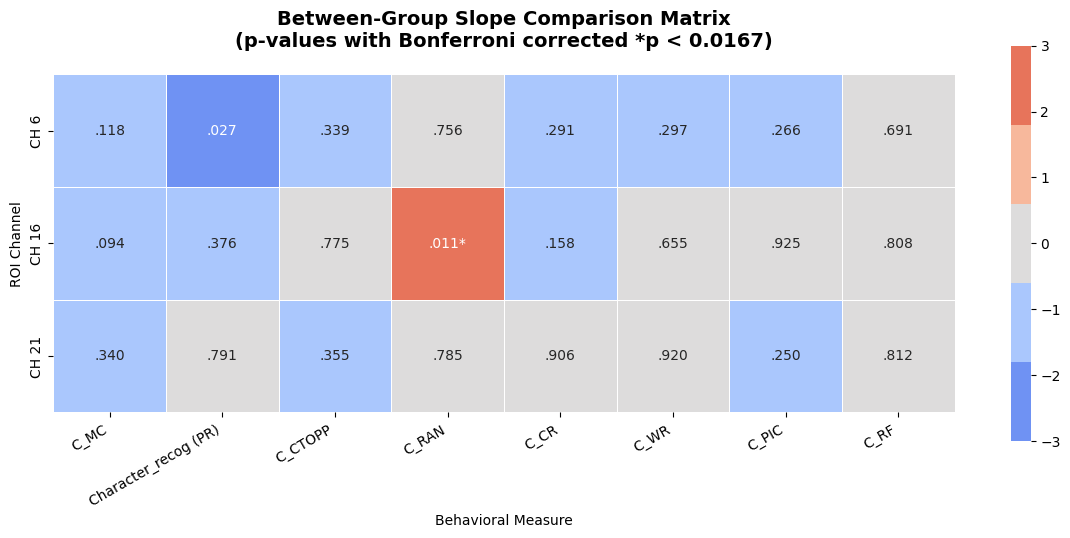

In [13]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 💾 1. 直接沿用妳記憶體中已讀取的 df_beta_td 與 df_beta_dd，徹底繞過路徑地雷
# =========================================================================
print("正在整合原始大腦 Beta 數據變數 (每組基準 N = 30)...")

# 確保乾淨複製，避免影響到妳之前的 dataframe
td_temp = df_beta_td.copy()
dd_temp = df_beta_dd.copy()

# 欄位去空格確保格式一致
for temp_df in [td_temp, dd_temp]:
    temp_df.columns = temp_df.columns.str.strip()

# 合併兩組數據成單一長表
brain_df = pd.concat([td_temp, dd_temp], ignore_index=True)

# 篩選 cond == 'MA' 實驗情境
target_cond = 'MA'
brain_df = brain_df[brain_df['cond'] == target_cond]

# 定義要分析的 3 個感興趣通道與 9 個行為指標
target_channels = [6, 16, 21]
behaviors = ['C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF']

between_group_results = []

# =========================================================================
# 🛠️ 2. 核心組間分析管線 (Between-group Fisher's Z Test)
# =========================================================================
print("開始進行組間 (Between-group) 迴歸線斜率差異檢定...")

# 💡 核心修正：嚴格的 Bonferroni 校正水準：0.05 / 3 = 0.0167
alpha_corrected = 0.05 / 3

for ch in target_channels:
    ch_df = brain_df[brain_df['Channel'] == ch]

    for bh in behaviors:
        if bh not in final_df.columns:
            continue

        merged_df = pd.merge(final_df[['ID', bh]], ch_df[['Subject', 'Group', 'Beta']], left_on='ID', right_on='Subject', how='inner')

        td_data = merged_df[merged_df['Group'] == 'TD'].dropna(subset=[bh, 'Beta'])
        dd_data = merged_df[merged_df['Group'] == 'DD'].dropna(subset=[bh, 'Beta'])

        n_td = len(td_data)
        n_dd = len(dd_data)

        if n_td <= 3 or n_dd <= 3:
            continue

        r_td, _ = stats.pearsonr(td_data[bh], td_data['Beta'])
        r_dd, _ = stats.pearsonr(dd_data[bh], dd_data['Beta'])

        z_td = np.arctanh(np.clip(r_td, -0.9999, 0.9999))
        z_dd = np.arctanh(np.clip(r_dd, -0.9999, 0.9999))

        se_diff = np.sqrt(1 / (n_td - 3) + 1 / (n_dd - 3))

        z_stat = (z_td - z_dd) / se_diff
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

        between_group_results.append({
            'ROI_Channel': f"CH {ch}", # 💡 修正通道命名格式，與前一版熱圖的 'CH 6' 一致
            'Behavioral_Measure': bh,
            'TD_N': n_td,
            'DD_N': n_dd,
            'TD_Group_r': round(r_td, 3),
            'DD_Group_r': round(r_dd, 3),
            'Between_Group_Z': round(z_stat, 3),
            'Between_Group_p': p_val, # 保留完整數值供後續製圖使用
            # 💡 核心修正：判定標準改為小於 alpha_corrected (0.0167)
            'Slope_Significantly_Different': '★ TRUE' if p_val < alpha_corrected else 'No'
        })

df_between_group = pd.DataFrame(between_group_results)

print("\n==================== 💡 【組間 (Between-group)】斜率差異檢定總表 ====================")
display(df_between_group)

excel_output_name = 'Between_Group_Slope_Comparison_Results.xlsx'
df_between_group.to_excel(excel_output_name, index=False)
print(f"\n💾 統計結果已成功存檔為 Excel 檔案：'{excel_output_name}'")

# =========================================================================
# 🎨 3. 繪製並存檔全新的「組間交互作用顯著差異熱圖」 (藍白紅5級 + p數據去0 + 4:3比例格子)
# =========================================================================
if not df_between_group.empty:
    p_matrix = df_between_group.pivot(index='ROI_Channel', columns='Behavioral_Measure', values='Between_Group_p')
    available_behaviors = [b for b in behaviors if b in p_matrix.columns]
    p_matrix = p_matrix[available_behaviors]

    # 💡 修正通道順序，確保由上到下是 CH 6, CH 16, CH 21
    expected_channels = [f"CH {ch}" for ch in target_channels]
    p_matrix = p_matrix.reindex(expected_channels)

    # 建立統計文字矩陣 (去除前導 0 且嚴格過濾星號)
    matrix_annot = pd.DataFrame(index=p_matrix.index, columns=p_matrix.columns)
    for i in range(p_matrix.shape[0]):
        for j in range(p_matrix.shape[1]):
            p_val = p_matrix.iloc[i, j]
            if not np.isnan(p_val):
                p_str = f"{p_val:.3f}".lstrip('0')
                if p_str == '1.000' or p_str == '1.': p_str = '1.00'
                if p_str == '': p_str = '.000'

                # 💡 核心修正：只有 p < 0.0167 的黃金格子才會被打上星號
                if p_val < alpha_corrected:
                    matrix_annot.iloc[i, j] = f"{p_str}*"
                else:
                    matrix_annot.iloc[i, j] = p_str
            else:
                matrix_annot.iloc[i, j] = "NaN"

    # 為了維持原本藍白紅分5級的視覺直覺，但因為這張圖是「組間差異」
    # 我們將 Z 統計量拿來作為色彩填色的依據（Z值越大或越小，代表兩組迴歸線對撞越激烈）
    z_matrix = df_between_group.pivot(index='ROI_Channel', columns='Behavioral_Measure', values='Between_Group_Z')
    z_matrix = z_matrix[available_behaviors].reindex(expected_channels)

    # 💡 修正畫面比例與標題：左右並排模式中，如果只有一張圖，我們可以將 figsize 設定為寬度適中 (12, 5)
    # 並搭配 square=True，格子就會變成漂亮的 4:3 比例正方形
    plt.figure(figsize=(12, 5))

    # 💡 修正標題：徹底洗乾淨，拿掉干擾的字眼
    plt.title("Between-Group Slope Comparison Matrix\n(p-values with Bonferroni corrected *p < 0.0167)", fontsize=14, fontweight='bold', pad=20)

    color_map_scale = sns.color_palette("coolwarm", 5)
    v_min_scale, v_max_scale = -3.0, 3.0 # Z 值的標準範圍設定

    # 繪製交互作用熱圖 (由 Z 決定顏色，由過校正的 P 值決定格內文字與星號)
    sns.heatmap(z_matrix.astype(float), annot=matrix_annot, fmt="", cmap=color_map_scale,
                vmin=v_min_scale, vmax=v_max_scale, linewidths=0.5, cbar=True, square=True)

    plt.xlabel('Behavioral Measure')
    plt.ylabel('ROI Channel')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    output_img_name = 'between_group_interaction_heatmap_final.png'
    plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
    print(f"🎨 組間交互作用熱圖視覺化完成！已儲存為圖檔：'{output_img_name}'")
    plt.show()